# Model Evaluation for Classification

In this notebook we evaluate classification models using multiple performance metrics.

We will demonstrate:

- Confusion Matrix
- Precision
- Recall
- F1 Score
- Overfitting vs Underfitting
- Model Complexity Visualization

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load Dataset
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Feature Selection
features = ["Pclass","Age","Fare"]

X = df[features]
y = df["Survived"]

X = X.fillna(X.mean())

In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

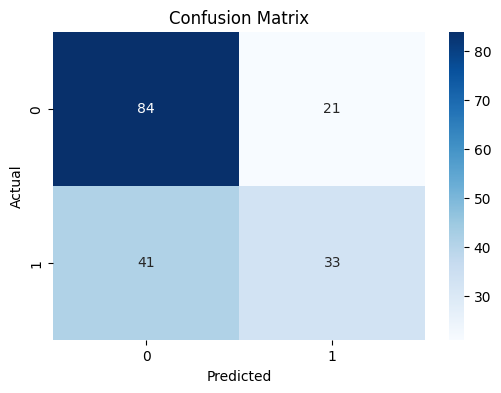

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

True Positive
<br />True Negative
<br />False Positive
<br />False Negative

In [7]:
# Classification Report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73       105
           1       0.61      0.45      0.52        74

    accuracy                           0.65       179
   macro avg       0.64      0.62      0.62       179
weighted avg       0.65      0.65      0.64       179



Overfitting vs Underfitting

Now we analyze model complexity.

For KNN:

small k → overfitting  
large k → underfitting

In [8]:
# Train KNN with Different k Values
train_accuracy = []
test_accuracy = []

k_values = range(1,21)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    train_accuracy.append(knn.score(X_train,y_train))
    test_accuracy.append(knn.score(X_test,y_test))

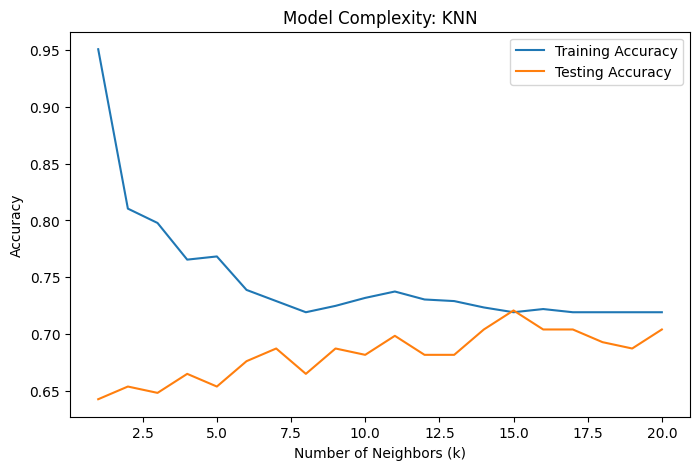

In [9]:
# Model Complexity Visualization
plt.figure(figsize=(8,5))

plt.plot(k_values, train_accuracy, label="Training Accuracy")
plt.plot(k_values, test_accuracy, label="Testing Accuracy")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")

plt.title("Model Complexity: KNN")

plt.legend()

plt.show()

k = 1 → overfitting
<br />large k → underfitting
<br />optimal k → balanced performance

## Key Insights

- Model evaluation should not rely only on accuracy.
- Precision, recall and F1-score provide deeper insight into classification performance.
- KNN model complexity is controlled by the number of neighbors.
- Small k values lead to overfitting.
- Large k values lead to underfitting.
- The optimal k value balances bias and variance.